In [17]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df= pd.read_excel('Final.xlsx')

In [19]:
df

,Batch-Factor,Factor,Downtime_Minutes,Batch,Description,Operator_Error,Date,Product,Operator,Start Time,End Time,Flavor,Size_ml,Min batch time,Start-Time,End-Time,Fact-Min-batch-time,Net_Production_time,Efficiency,Actual Working Ratio,over time,Downtime_Ratio,Performance_loss,Is_Efficient,Day_of_Week
0,5000014,4,9,500001,Inventory shortage,0,2025-01-01,DC-600,frank,00:00:00,01:09:00,diet cola,600,60,00:00,01:09,69,60,1.00,0.87,9,0.13,0,1,Wednesday
1,5000044,4,10,500004,Inventory shortage,0,2025-01-01,DC-600,charlie,03:47:00,04:57:00,diet cola,600,60,03:47,04:57,70,60,1.00,0.86,10,0.14,0,1,Wednesday
2,50002710,10,7,500027,Calibration error,1,2025-01-02,DC-600,heidi,20:47:00,21:54:00,diet cola,600,60,20:47,21:54,67,60,1.00,0.90,7,0.10,0,1,Thursday
3,5000037,7,17,500003,Machine failure,0,2025-01-01,LE-600,charlie,02:09:00,03:47:00,lemon lime,600,60,02:09,03:47,98,81,0.74,0.83,38,0.17,-21,0,Wednesday
4,5000071,1,28,500007,Emergency stop,0,2025-01-01,CO-2L,dennis,09:59:00,12:45:00,cola,2000,98,09:59,12:45,166,138,0.71,0.83,68,0.17,-40,0,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5004698,8,24,500469,Batch coding error,1,2025-02-02,RB-600,mac,07:45:00,10:30:00,root berry,600,60,07:45,10:30,165,141,0.43,0.85,105,0.15,-81,0,Sunday
996,5008924,4,12,500892,Inventory shortage,0,2025-03-04,CO-600,frank,00:41:00,02:13:00,cola,600,60,00:41,02:13,92,80,0.75,0.87,32,0.13,-20,0,Tuesday
997,5006345,5,28,500634,Product spill,1,2025-02-13,CO-600,dennis,14:56:00,17:45:00,cola,600,60,14:56,17:45,169,141,0.43,0.83,109,0.17,-81,0,Thursday
998,50089212,12,7,500892,Other,0,2025-03-04,CO-600,frank,00:41:00,02:13:00,cola,600,60,00:41,02:13,92,85,0.71,0.92,32,0.08,-25,0,Tuesday


In [ ]:
Index(['Batch-Factor', 'Factor', 'Downtime_Minutes', 'Batch', 'Description',
       'Operator_Error', 'Date', 'Product', 'Operator', 'Start Time',
       'End Time', 'Flavor', 'Size_ml', 'Min batch time', 'Start-Time',
       'End-Time', 'Fact-Min-batch-time', 'Net_Production_time', 'Efficiency',
       'Actual Working Ratio', 'over time', 'Downtime_Ratio',
       'Performance_loss', 'Is_Efficient', 'Calculated_Downtime_Ratio'],
      dtype='object')

In [20]:
df.columns

Index(['Batch-Factor', 'Factor', 'Downtime_Minutes', 'Batch', 'Description',
       'Operator_Error', 'Date', 'Product', 'Operator', 'Start Time',
       'End Time', 'Flavor', 'Size_ml', 'Min batch time', 'Start-Time',
       'End-Time', 'Fact-Min-batch-time', 'Net_Production_time', 'Efficiency',
       'Actual Working Ratio', 'over time', 'Downtime_Ratio',
       'Performance_loss', 'Is_Efficient', 'Day_of_Week'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Batch-Factor          1000 non-null   int64         
 1   Factor                1000 non-null   int64         
 2   Downtime_Minutes      1000 non-null   int64         
 3   Batch                 1000 non-null   int64         
 4   Description           1000 non-null   object        
 5   Operator_Error        1000 non-null   int64         
 6   Date                  1000 non-null   datetime64[ns]
 7   Product               1000 non-null   object        
 8   Operator              1000 non-null   object        
 9   Start Time            1000 non-null   object        
 10  End Time              1000 non-null   object        
 11  Flavor                1000 non-null   object        
 12  Size_ml               1000 non-null   int64         
 13  Min batch time     

In [22]:


# لإظهار جميع الأعمدة في الإخراج
pd.set_option('display.max_columns', None)

# تحويل الأعمدة الزمنية والتاريخ
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# تحويل الأعمدة الرقمية الهامة إلى نوع float والتعامل مع الأخطاء
numerical_cols = [
    'Downtime_Minutes', 'Min batch time', 'Fact-Min-batch-time',
    'Net_Production_time', 'Efficiency', 'Actual Working Ratio',
    'Downtime_Ratio', 'Performance_loss', 'over time'
]

# --- 3. إنشاء متغيرات تحليلية إضافية (Feature Engineering) ---
# حساب نسبة وقت التوقف الفعلي للتأكد
df['Calculated_Downtime_Ratio'] = df['Downtime_Minutes'] / df['Fact-Min-batch-time']
# تنظيف قيم النسبة اللانهائية الناتجة عن القسمة على صفر (حيث Fact-Min-batch-time قد تكون صفر)
df['Calculated_Downtime_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['Calculated_Downtime_Ratio'] = df['Calculated_Downtime_Ratio'].fillna(0) # استبدال NaN بعد التحويل بـ 0 إذا كان منطقيا

# عرض ملخص بعد التنظيف
print("="*50)
print("✅ بيانات نظيفة وجاهزة للتحليل:")
df.info()
print("\nأول 5 صفوف بعد التنظيف:")
print(df.head())
print("="*50)

✅ بيانات نظيفة وجاهزة للتحليل:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Batch-Factor               1000 non-null   int64         
 1   Factor                     1000 non-null   int64         
 2   Downtime_Minutes           1000 non-null   int64         
 3   Batch                      1000 non-null   int64         
 4   Description                1000 non-null   object        
 5   Operator_Error             1000 non-null   int64         
 6   Date                       1000 non-null   datetime64[ns]
 7   Product                    1000 non-null   object        
 8   Operator                   1000 non-null   object        
 9   Start Time                 1000 non-null   object        
 10  End Time                   1000 non-null   object        
 11  Flavor                     1000 non-nul

C:\Users\laptop home\AppData\Local\Temp\ipykernel_18008\2088099602.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Calculated_Downtime_Ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)


In [23]:
# --- 1. الإحصاء الوصفي وتوزيع الكفاءة ونسبة التوقف ---

print("\n### الإحصاء الوصفي للمقاييس الرئيسية ###")
df[['Efficiency', 'Downtime_Minutes', 'Calculated_Downtime_Ratio', 'Performance_loss']].describe()



### الإحصاء الوصفي للمقاييس الرئيسية ###


,Efficiency,Downtime_Minutes,Calculated_Downtime_Ratio,Performance_loss
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.764540,22.714000,0.198137,-23.961000
std,0.159743,13.928324,0.102569,18.886561
min,0.410000,5.000000,0.031056,-87.000000
25%,0.650000,13.000000,0.125000,-36.000000
50%,0.740000,20.500000,0.183791,-24.000000
75%,0.900000,28.000000,0.245366,-7.000000
max,1.000000,87.000000,0.577465,0.000000


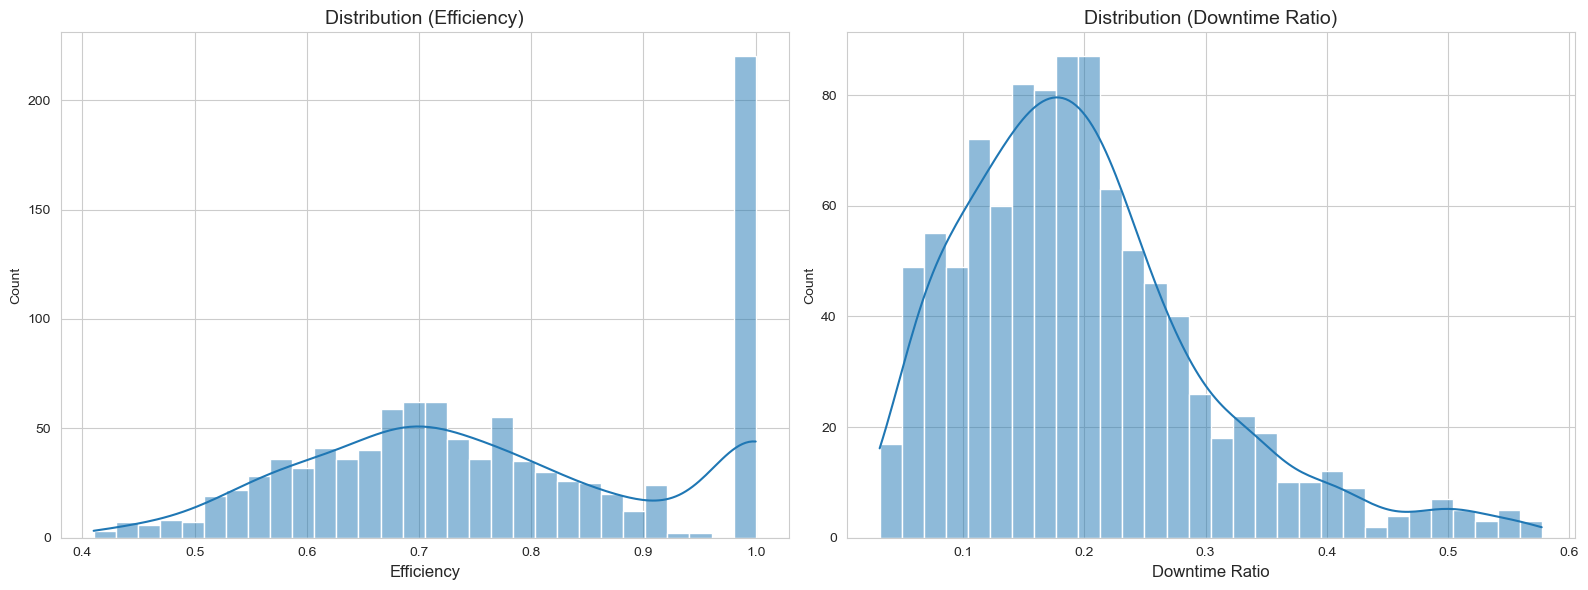

In [24]:
# توزيع الكفاءة ونسبة وقت التوقف (Visualization)
sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Efficiency'], kde=True, bins=30)
plt.title('Distribution (Efficiency)', fontsize=14)
plt.xlabel('Efficiency', fontsize=12)

plt.subplot(1, 2, 2)
sns.histplot(df['Calculated_Downtime_Ratio'], kde=True, bins=30)
plt.title('Distribution (Downtime Ratio)', fontsize=14)
plt.xlabel('Downtime Ratio', fontsize=12)

plt.tight_layout()
plt.show()


In [25]:
# --- 2. تحليل الارتباط (Correlation Analysis) ---

correlation_cols = ['Efficiency', 'Downtime_Minutes', 'Actual Working Ratio', 'Performance_loss', 'over time', 'Calculated_Downtime_Ratio']
correlation_matrix = df[correlation_cols].corr()

print("\n### مصفوفة الارتباط لمؤشرات الأداء (Correlation Matrix) ###")
correlation_matrix



### مصفوفة الارتباط لمؤشرات الأداء (Correlation Matrix) ###


,Efficiency,Downtime_Minutes,Actual Working Ratio,Performance_loss,over time,Calculated_Downtime_Ratio
Efficiency,1.000000,0.168747,-0.397849,0.952050,-0.731384,0.398311
Downtime_Minutes,0.168747,1.000000,-0.913805,0.178611,0.493887,0.914326
Actual Working Ratio,-0.397849,-0.913805,1.000000,-0.438080,-0.208408,-0.999619
Performance_loss,0.952050,0.178611,-0.438080,1.000000,-0.767330,0.438277
over time,-0.731384,0.493887,-0.208408,-0.767330,1.000000,0.208573
Calculated_Downtime_Ratio,0.398311,0.914326,-0.999619,0.438277,0.208573,1.000000


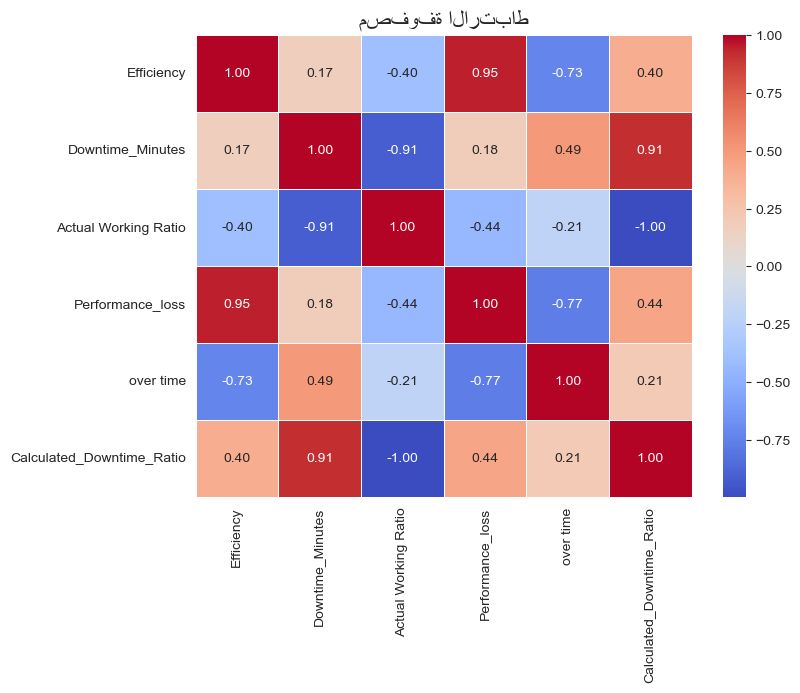

In [26]:

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('مصفوفة الارتباط', fontsize=16)
plt.show()


In [27]:
# --- 3. التحليل الشرطي المتقدم (Conditional Analysis) ---

# الرؤية 1: متوسط خسارة الأداء حسب سبب التوقف والمنتج
print("\n### جدول محوري: متوسط خسارة الأداء (Performance Loss) حسب السبب والمنتج (التركيبات الأسوأ) ###")
pivot_loss = df.pivot_table(
    values='Performance_loss',
    index='Description',
    columns='Product',
    aggfunc='mean'
)


### جدول محوري: متوسط خسارة الأداء (Performance Loss) حسب السبب والمنتج (التركيبات الأسوأ) ###


In [28]:
# عرض أعلى 10 أسباب متوسطة للخسارة الإجمالية
pivot_loss['Overall_Avg'] = pivot_loss.mean(axis=1)
pivot_loss.sort_values(by='Overall_Avg', ascending=False).head(10).drop(columns=['Overall_Avg'])



Product,CO-2L,CO-600,DC-600,LE-600,OR-600,RB-600
Description,,,,,,
Batch change,-21.609756,-18.916667,-13.406250,-14.605263,-15.162162,-16.000000
Label switch,-25.705882,-17.250000,-23.571429,-21.000000,-21.000000,-22.900000
Machine adjustment,-18.500000,-38.300000,-28.000000,-21.941176,-20.222222,-15.909091
Product spill,-20.153846,-33.375000,-18.000000,-32.000000,-22.090909,-17.769231
Batch coding error,-19.583333,-43.272727,-11.142857,-24.625000,-16.111111,-31.777778
Other,-5.750000,-25.166667,-28.833333,-42.928571,-16.500000,-29.117647
Conveyor belt jam,-28.222222,-16.444444,-30.714286,-28.294118,-22.666667,-27.750000
Emergency stop,-29.000000,-31.000000,-18.250000,-26.846154,-27.071429,-25.000000
Inventory shortage,-26.666667,-31.777778,-18.071429,-30.066667,-25.454545,-29.875000


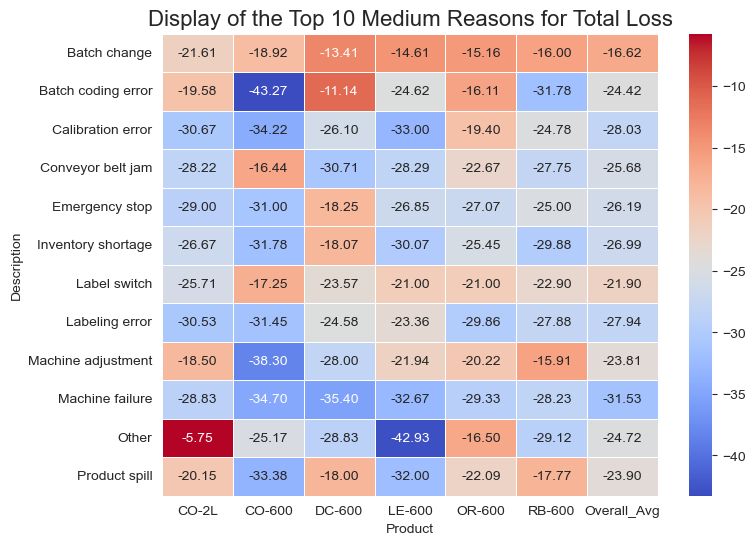

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_loss, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Display of the Top 10 Medium Reasons for Total Loss', fontsize=16)
plt.show()


In [15]:
# الرؤية 2: متوسط الكفاءة حسب المشغل ويوم الأسبوع
print("\n### جدول محوري: متوسط الكفاءة (Efficiency) حسب المشغل ويوم الأسبوع ###")
pivot_efficiency = df.pivot_table(
    values='Efficiency',
    index='Operator',
    columns='Day_of_Week',
    aggfunc='mean'
)
pivot_efficiency.sort_values(by=pivot_efficiency.columns[0], ascending=False)



### جدول محوري: متوسط الكفاءة (Efficiency) حسب المشغل ويوم الأسبوع ###


Day_of_Week,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Operator,,,,,,,
dennis,0.880000,0.776957,0.796667,0.820000,0.792667,0.848182,0.827143
mac,0.795455,0.777273,0.797895,0.751176,0.731600,0.798500,0.725946
dee,0.794211,0.795000,0.792000,0.834000,0.733200,0.711579,0.745000
heidi,0.780000,0.735652,0.724091,0.854444,0.736176,0.768261,0.807273
grace,0.731538,0.730000,0.776364,0.802778,0.745185,0.759444,0.748889
ivan,0.730606,0.753529,0.797273,0.737500,0.709091,0.756250,0.842857
frank,0.680556,0.803571,0.683684,0.762400,0.817000,0.803333,0.820769
charlie,0.667778,0.821429,0.802000,0.836471,0.789130,0.706154,0.729200


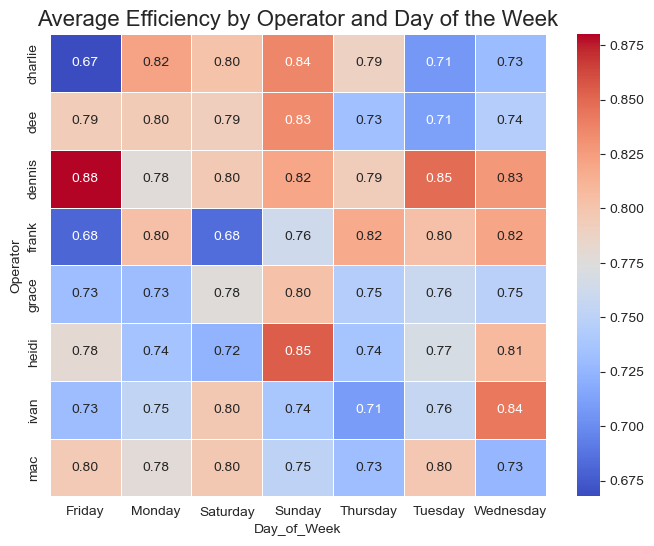

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_efficiency, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Average Efficiency by Operator and Day of the Week', fontsize=16)
plt.show()
